In [1]:
import os
import sys
from pathlib import Path

sys.path.insert(0, str(Path(os.environ['CONDA_PREFIX']).absolute() / 'nsight-compute-2025.2.1' / 'extras' / 'python')
                )

In [2]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
from pathlib import Path

# rcParams.update({
#     "text.usetex": True,
#     'text.latex.preamble': r'\usepackage{amsmath}\usepackage{amssymb}',
#     'pgf.texsystem': 'pdflatex',
#     'pgf.preamble': '',
#     "font.family": "serif",
#     "font.serif": ["times"],
#     "axes.unicode_minus": False
# })
# plt.rc('xtick', top=True, bottom=True, labelsize=30, direction='in')
# plt.rc('ytick', left=True, right=True, labelsize=30, direction='in')
# plt.rc('xtick.major', size=16, pad=12, width=2.5)
# plt.rc('ytick.major', size=16, pad=12, width=2.5)
# plt.rc('xtick.minor', size=8, width=1.5)
# plt.rc('ytick.minor', size=8, width=1.5)
# plt.rc('axes', titlesize=35, labelsize=30, titleweight='bold', titlepad=20)
# plt.rc('figure', titlesize=35)
# plt.rc('legend', fontsize=20, title_fontsize=30, frameon=True, framealpha=1)

In [3]:
from ncu_occupancy import *

In [4]:
get_gpu_data(8, 6)

{'cc_major': 8,
 'cc_minor': 6,
 'sm_version': 'sm_86',
 'threads_per_warp': 32,
 'max_warps_per_sm': 48,
 'max_threads_per_sm': 1536,
 'max_thread_blocks_per_sm': 16,
 'block_barriers_per_sm': 16,
 'smem_per_sm': 102400,
 'max_shared_mem_per_block': 102400,
 'registers_per_sm': 65536,
 'max_regs_per_block': 65536,
 'max_regs_per_thread': 255,
 'reg_allocation_unit_size': 256,
 'reg_allocation_granularity': 'warp',
 'shared_mem_allocation_unit_size': 128,
 'warps_allocation_granularity': 4,
 'max_thread_block_size': 1024,
 'shared_mem_size_configs': [102400, 65536, 32768, 16384, 8192, 0],
 'warp_reg_allocation_granularities': [256]}

In [5]:
def compute(ccM, ccm, tpb, reg, smem=16384):
    return float(
        OccupancyCalculator(ccM, ccm).get_sm_occupancy(OccupancyParameters(int(smem), int(tpb), int(reg), 0, 0)))

In [6]:
rcParams.update({
    "text.usetex": True,
    'text.latex.preamble': r'\usepackage{amsmath}\usepackage{amssymb}',
    'pgf.texsystem': 'pdflatex',
    'pgf.preamble': '',
    "font.family": "serif",
    "font.serif": ["times"],
    "axes.unicode_minus": False
})
plt.rc('xtick', top=True, bottom=True, labelsize=15, direction='in')
plt.rc('ytick', left=True, right=True, labelsize=15, direction='in')
# plt.rc('xtick.major', size=16, pad=12, width=1)
# plt.rc('ytick.major', size=16, pad=12, width=1)
# plt.rc('xtick.minor', size=8, width=0.5)
# plt.rc('ytick.minor', size=8, width=0.5)
plt.rc('axes', titlesize=20, labelsize=20, titleweight='bold', titlepad=0, labelpad=12)
# plt.rc('figure', titlesize=35)
# plt.rc('legend', fontsize=20, title_fontsize=30, frameon=True, framealpha=1)

In [7]:
import matplotlib.colors as mcolors

def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=256):
    """Truncates a colormap to a specific range."""
    new_cmap = mcolors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n))
    )
    return new_cmap

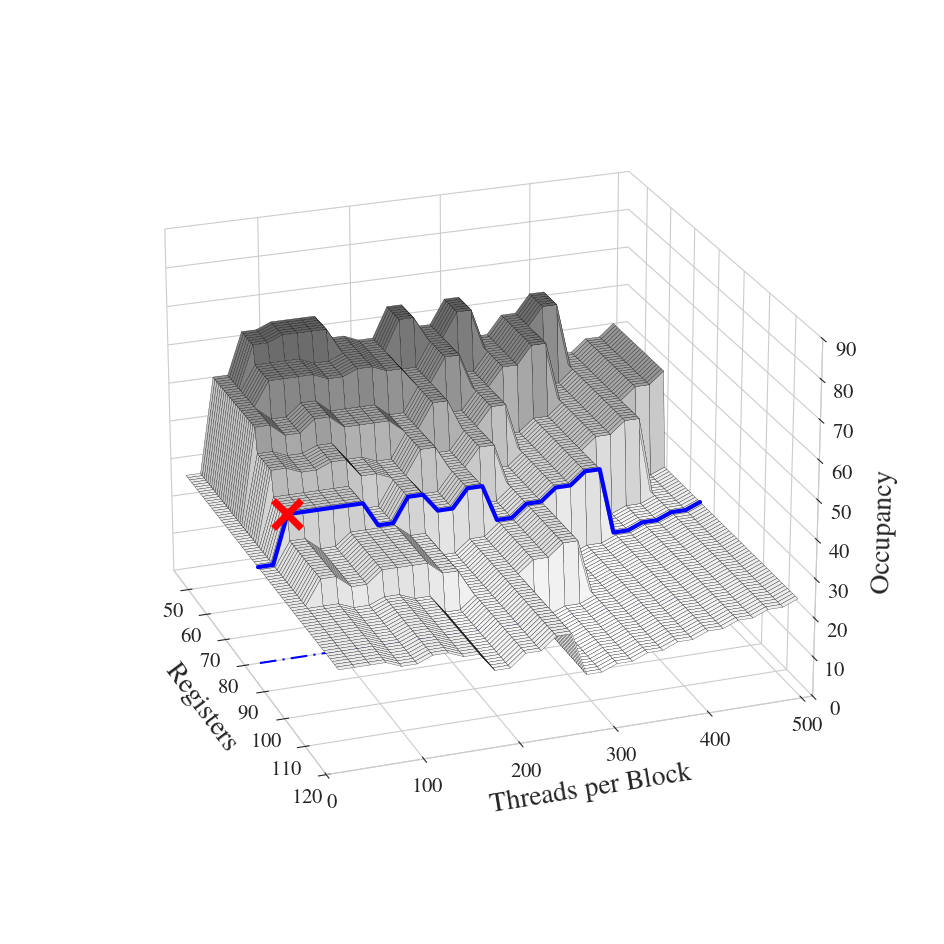

In [12]:
from matplotlib.transforms import Bbox
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np

ccM, ccm = 8, 0

x_vals = np.array(list(range(42, 120, 1)))
y_vals = np.array(list(range(16, 512, 16)))
X, Y = np.meshgrid(x_vals, y_vals)

Z = np.zeros_like(X, dtype=float)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        Z[i, j] = compute(ccM, ccm, int(Y[i, j]), int(X[i, j]))

fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(111, projection='3d')
# fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': '3d'}, constrained_layout=True,
#                        gridspec_kw=dict(right=1.2))
ax.set_xlim((42, 120))
ax.set_ylim((0, 512))
ax.set_zlim((0, 90))
ax.set_xlabel('Registers')
ax.set_ylabel('Threads per Block')
ax.set_zlabel('Occupancy')

POINT = (80, 48)

ax.plot([POINT[0]] * len(y_vals),
        y_vals,
        [compute(ccM, ccm, int(x), POINT[0]) for x in y_vals],
        c='blue', linewidth=3,
        zorder=10)
ax.plot([POINT[0]], [POINT[1]], [compute(ccM, ccm, POINT[1], POINT[0])], zorder=100,
        markeredgecolor='red', markeredgewidth=5,
        markerfacecolor='red', marker='x', markersize=20)
ax.plot([POINT[0]] * len(y_vals),
        y_vals,
        [0] * len(y_vals),
        c='blue', linewidth=1.5, linestyle=(0, (8, 3, 1, 3)),
        zorder=-1)

original_cmap = plt.get_cmap('Greys')
truncated_cmap = truncate_colormap(original_cmap, 0.0, 0.7)
ax.plot_surface(X, Y, Z, cmap=truncated_cmap, alpha=1, rstride=1, cstride=1, linewidth=.2, edgecolors='k')

ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))

ax.view_init(23, -20, 0)
ax.set_box_aspect(None, zoom=0.85)

plt.savefig(str(Path().resolve().parent / 'data' / 'publications' / f'cc_occupancy_{ccM}_{ccm}.pdf'), bbox_inches='tight', pad_inches=0.2)
plt.show()

# spring aqua lime
# bone lime red

In [9]:
compute(ccM, ccm, POINT[1], POINT[0])

50.0

In [10]:
import plotly.graph_objects as go

POINT = (80, 48)

fig = go.Figure()

# fig.add_trace(go.Surface(x=X, y=Y, z=Z, colorscale='Armyrose',
#                          showscale=False,
#                          contours=dict(
#                              x=dict(show=True, start=np.min(X), end=np.max(X), size=5, color="black"),
#                              y=dict(show=True, start=np.min(Y), end=np.max(Y), size=5, color="black"),
#                              z=dict(show=True, start=np.min(Z), end=np.max(Z), size=5, color="black"),
#                          )))

fig.add_trace(go.Surface(
    x=X,
    y=Y,
    z=Z,
    colorscale='Armyrose',
    showscale=False,
    contours=dict(
        x=dict(show=True, size=(X[0, 1] - X[0, 0]), color="black"),
        y=dict(show=True, size=(Y[1, 0] - Y[0, 0]), color="black"),
        z=dict(show=True, size=(np.min(np.diff(np.unique(Z)))), color="black"),
    )
))

line_z = [compute(8, 6, int(x), POINT[0]) for x in y_vals]
print(line_z)
fig.add_trace(go.Scatter3d(x=[POINT[0]] * len(y_vals), y=y_vals, z=line_z,
                           mode='lines',
                           line=dict(color='red', width=10)))

point_z = compute(8, 6, POINT[1], POINT[0])
fig.add_trace(go.Scatter3d(x=[POINT[0]], y=[POINT[1]], z=[point_z],
                           mode='markers',
                           marker=dict(color='dodgerblue', size=10, symbol='circle')))

fig.update_layout(
    # title='3D Plot',
    font_family='Serif',
    scene=dict(
        xaxis_title='registers',
        yaxis_title='threads per block',
        zaxis_title='occupancy',
        camera=dict(
            eye=dict(x=2, y=-.7, z=.8)
        )
    ),
    margin=dict(l=0, r=0, b=0, t=40),
    autosize=False,
    width=800,
    height=800,
    showlegend=False,
)

fig.show()

[33.333335876464844, 33.333335876464844, 50.0, 50.0, 50.0, 50.0, 50.0, 50.0, 41.666664123535156, 41.666664123535156, 50.0, 50.0, 43.75, 43.75, 50.0, 50.0, 37.5, 37.5, 41.666664123535156, 41.666664123535156, 45.833335876464844, 45.833335876464844, 50.0, 50.0, 27.08333396911621, 27.08333396911621, 29.16666603088379, 29.16666603088379, 31.25, 31.25, 33.333335876464844]


In [11]:
fig.write_image(Path().resolve().parent / 'data' / 'publications' / 'cc_plot.pdf', )